In [1]:
# -- ANÁLISE EXPLORATÓRIO DO DATASET VENDAS NO PERÍODO DE 2023 À 2024 --
# Objetivo: Analisar inicialmente os dados da tabela e verificar se é passível de tratamento

# Importando a biblioteca pandas para manipulação de dados e leitura do arquivo CSV
import pandas as pd
df = pd.read_csv("datasets/vendas_2023_2024.csv")
df.head()  # Exibe as primeiras linhas do DataFrame para uma visão geral dos dados

,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,3405.0,2023-09-10
1,1,3,136,9,16873.9,15-09-2024
2,2,25,139,7,9475.3,2024-08-13
3,4,20,23,5,55893.0,2023-02-03
4,5,8,57,4,451403.9,2024-02-12


In [100]:
df.tail()  # Exibe as últimas linhas do DataFrame para verificar os dados no final do arquivo

,id,id_client,id_product,qtd,total,sale_date
9890,9995,30,139,6,8549.00,11-03-2023
9891,9996,9,111,7,28497.15,17-09-2023
9892,9997,38,123,2,5276.30,20-06-2023
9893,9998,33,97,6,771409.50,23-10-2024
9894,9999,8,20,6,185001.00,15-06-2023


In [101]:
df.info() # Exibe informações sobre o DataFrame, incluindo tipos de dados e contagem de valores não nulos

<class 'pandas.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          9895 non-null   int64  
 1   id_client   9895 non-null   int64  
 2   id_product  9895 non-null   int64  
 3   qtd         9895 non-null   int64  
 4   total       9895 non-null   float64
 5   sale_date   9895 non-null   str    
dtypes: float64(1), int64(4), str(1)
memory usage: 464.0 KB


In [102]:
df.describe() # Exibe estatísticas descritivas para as colunas numéricas do DataFrame

,id,id_client,id_product,qtd,total
count,9895.000000,9895.000000,9895.000000,9895.000000,9.895000e+03
mean,5000.755533,24.874583,75.255786,8.015260,2.637978e+05
std,2887.000000,14.177715,43.533397,4.301723,3.900072e+05
min,0.000000,1.000000,1.000000,1.000000,2.945000e+02
25%,2501.500000,13.000000,37.000000,4.000000,2.313820e+04
50%,4999.000000,25.000000,74.000000,8.000000,8.222500e+04
75%,7505.500000,37.000000,114.000000,12.000000,3.390945e+05
max,9999.000000,49.000000,150.000000,15.000000,2.222973e+06


In [103]:
df.isnull().sum() # Verifica a quantidade de valores nulos em cada coluna do DataFrame

id            0
id_client     0
id_product    0
qtd           0
total         0
sale_date     0
dtype: int64

In [104]:
verificar_virgula = df['total'].astype(str).str.contains(',')
verificar_virgula.sum() # Verifica quantos valores na coluna 'total' contêm vírgula, o que pode indicar um problema de formatação numérica

np.int64(0)

id               Axes(0.125,0.11;0.133621x0.77)
id_client     Axes(0.285345,0.11;0.133621x0.77)
id_product     Axes(0.44569,0.11;0.133621x0.77)
qtd           Axes(0.606034,0.11;0.133621x0.77)
total         Axes(0.766379,0.11;0.133621x0.77)
dtype: object

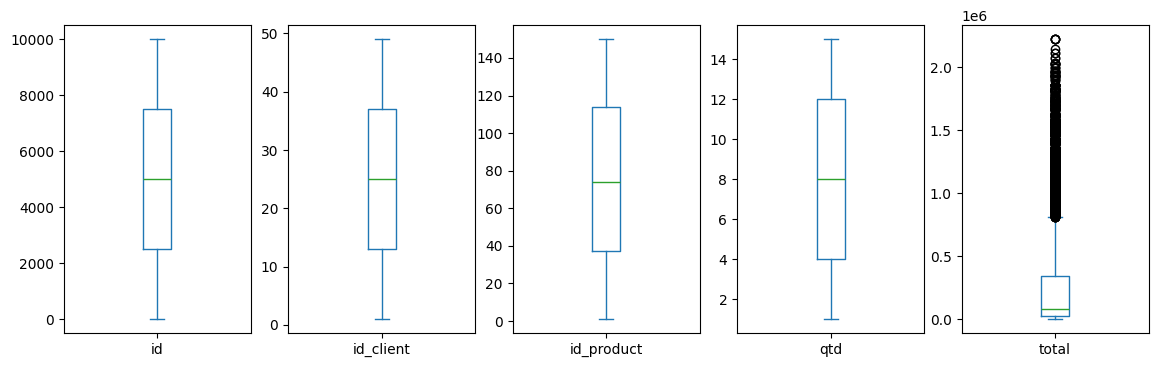

In [105]:
# Visualização de boxplot para identificar possíveis outliers nas colunas numéricas do DataFrame
df.plot(kind='box',figsize=(14,4),subplots=True) 

In [106]:
# Verificando a data mais recente presente no dataset para entender o período de vendas coberto
maior_data = df['sale_date'].max()
maior_data

'31-12-2024'

In [107]:
# Verificando a data mais antiga presente no dataset para entender o período de vendas coberto
menor_data = df['sale_date'].min()
menor_data

'01-01-2023'

In [108]:
# Verificando o maior valor de venda presente relacionando qtd e valor total para entender o valor máximo de venda registrado no dataset
maior_valor_de_venda = df['total'].max()
print(maior_valor_de_venda)

2222973.0


In [109]:
# Verificando o menor valor de venda presente relacionando qtd e valor total para entender o valor mínimo de venda registrado no dataset
menor_valor_de_venda = df['total'].min()
print(menor_valor_de_venda)

294.5


In [110]:
# Convertendo a coluna 'sale_date' para o tipo datetime
df['sale_date'] = df['sale_date'].astype('datetime64[us]')
df.info()  # Verifica novamente as informações do DataFrame para confirmar a conversão da coluna 'sale_date' para datetime

<class 'pandas.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          9895 non-null   int64         
 1   id_client   9895 non-null   int64         
 2   id_product  9895 non-null   int64         
 3   qtd         9895 non-null   int64         
 4   total       9895 non-null   float64       
 5   sale_date   9895 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(4)
memory usage: 464.0 KB


id               Axes(0.125,0.11;0.133621x0.77)
id_client     Axes(0.285345,0.11;0.133621x0.77)
id_product     Axes(0.44569,0.11;0.133621x0.77)
qtd           Axes(0.606034,0.11;0.133621x0.77)
total         Axes(0.766379,0.11;0.133621x0.77)
dtype: object

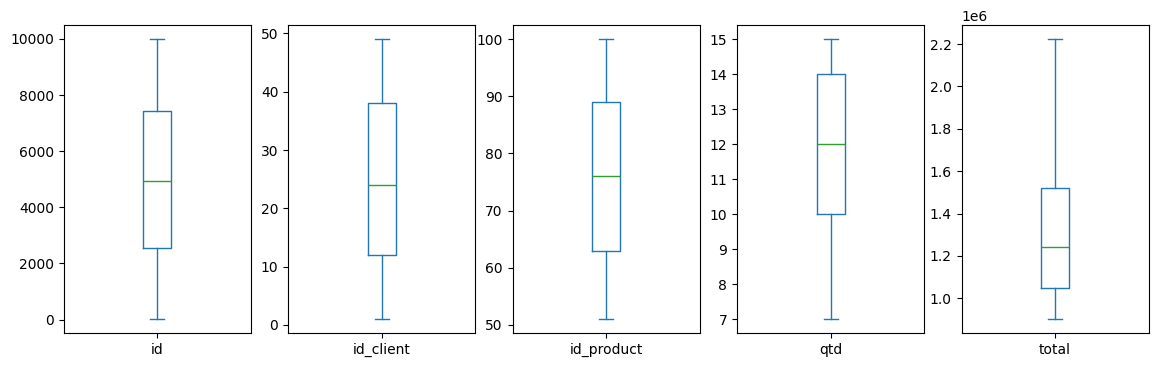

In [111]:
# Identificando outliers na coluna 'total' e visualizando-os com um boxplot
outliers = df[df['total'] > 900000]
outliers.plot(kind='box',figsize=(14,4),subplots=True)

In [112]:
import os
print(os.getcwd())  # Verifica o diretório de trabalho atual para garantir que o arquivo

c:\Users\Gabriel Prado\Documents\TESTE_INDICIUM


In [113]:
# Definindo o caminho completo para salvar o arquivo CSV dos outliers, garantindo que seja salvo na pasta correta
pasta = 'analisar_outliers'
arquivo = 'outliers.csv'
caminho_completo = os.path.join(pasta, arquivo)

In [114]:
# Verificando se a pasta existe antes de salvar o arquivo CSV dos outliers
if not os.path.exists(pasta):
    os.makedirs(pasta)  # Cria a pasta se ela não existir

In [115]:
# Notei uma alta variância nos dados, com um valor máximo de venda muito alto (900.000) e um valor mínimo de venda muito baixo (0). 
# Para uma análise mais precisa, decidi filtrar os dados para considerar apenas vendas com valores acima de 900000, 
# o que me permitirá focar em um intervalo mais representativo dos dados típicos de vendas.
# Salvando o DataFrame final em um novo arquivo CSV
outliers.to_csv(caminho_completo, index=False, sep=";", encoding='utf-8-sig')

id               Axes(0.125,0.11;0.133621x0.77)
id_client     Axes(0.285345,0.11;0.133621x0.77)
id_product     Axes(0.44569,0.11;0.133621x0.77)
qtd           Axes(0.606034,0.11;0.133621x0.77)
total         Axes(0.766379,0.11;0.133621x0.77)
dtype: object

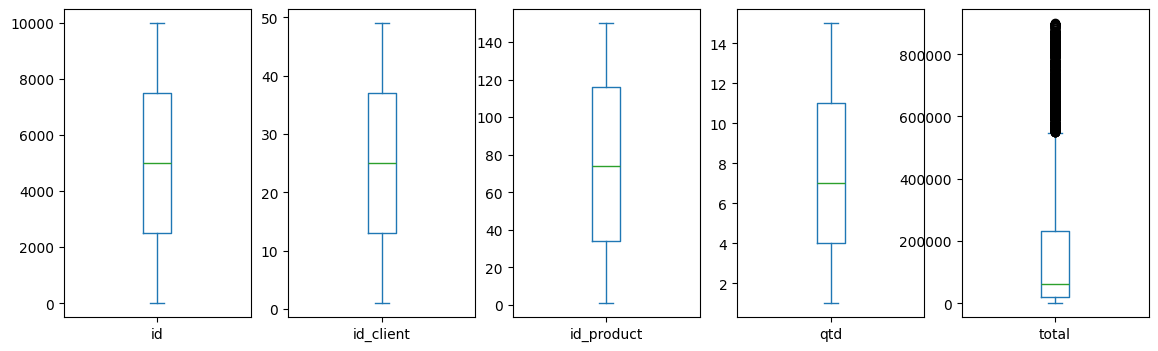

In [116]:
# Filtrando os dados para excluir os outliers e visualizando novamente com um boxplot
dados_tipicos = df[df['total'] < 900000]
dados_tipicos.plot(kind='box',figsize=(14,4),subplots=True)

In [117]:
pasta = 'analisar_dados_tipicos'
arquivo = 'dados_tipicos.csv'
caminho_completo = os.path.join(pasta, arquivo)

In [118]:
# Verificando se a pasta existe antes de salvar o arquivo CSV dos dados típicos
if not os.path.exists(pasta):
    os.makedirs(pasta)  # Cria a pasta se ela não existir

In [119]:
# Levando em conta a separação dos outliers, decidi salvar os dados típicos em um arquivo CSV separado para 
# facilitar análises futuras e garantir que os dados estejam organizados de forma clara.
# Salvando o DataFrame final em um novo arquivo CSV
dados_tipicos.to_csv(caminho_completo, index=False, sep=";", encoding='utf-8-sig')